# 13c. KV Cache Eviction for Long Contexts

**Tier:** Building with LLMs
**Estimated time:** 45 minutes
**Prerequisites:** 13 (context windows & KV cache), 13b (vLLM inference serving)
**Priority:** 🟡 Important — matters once a session runs longer than your KV budget. *If skipped, revisit when:* you're building a long-running chat or agent session and it starts truncating, slowing down, or running out of GPU memory mid-conversation.
**Source material:** Xiao et al., *"Efficient Streaming Language Models with Attention Sinks"* (ICLR 2024, StreamingLLM) — https://arxiv.org/abs/2309.17453; Zhang et al., *"H2O: Heavy-Hitter Oracle for Efficient Generative Inference of Large Language Models"* (NeurIPS 2023) — https://arxiv.org/abs/2306.14048.

## What You'll Learn
- Why the KV cache eventually runs out even with **paging** (notebook 13b) — paging manages memory *fragmentation*, not unbounded *growth*
- **Attention sinks** (StreamingLLM): why the first few tokens of any sequence soak up disproportionate attention regardless of their content, and how keeping just them plus a sliding window gets you stable infinite-length generation
- **Heavy hitters** (H2O): why a small set of *content* tokens — not just recent or first ones — carry most of a sequence's cumulative attention, and how to keep only those
- How to measure the real tradeoff: retained attention mass and next-token agreement vs. how much of the KV cache you're willing to throw away

## Why This Matters
Notebook 13b's PagedAttention makes memory *allocation* efficient — no more reserving a giant contiguous block per request. But it does nothing about the fact that a long-running chat session, or an agent that's been working for an hour, keeps *adding* tokens to the cache forever. Eventually you hit a hard ceiling: either the GPU runs out of memory, or the model's own trained context length. **Eviction** is the third lever, after quantization (10, 10b) and paging (13b): deciding which cached tokens to throw away so a session can run indefinitely inside a fixed memory budget, instead of growing until something breaks.


## Eviction is not the same thing as vLLM's "evict" in notebook 13b

Notebook 13b used the word "evict" for the scheduler *preempting* a whole request — swapping its entire KV cache out to make room for another request, then swapping it back in later. Nothing is thrown away there; it's memory management between requests.

This notebook's eviction is different: it happens **inside a single request's cache**, deleting individual cached tokens (not the whole sequence) that will never come back. That's a real, permanent loss of information, so the question is entirely about *which* tokens are safe to lose. A chat session that's exchanged 50,000 tokens with a user cannot keep all 50,000 forever on a fixed-size GPU — something has to go, and the difference between a good and bad eviction policy is the difference between "the model still remembers what mattered" and "the model degrades into gibberish."


In [1]:
import numpy as np
import torch

rng = np.random.default_rng(0)

def hf_reachable(timeout=1.5):
    """Fast reachability probe -- fails in ~1s instead of letting a model download hang."""
    import urllib.request
    try:
        urllib.request.urlopen("https://huggingface.co", timeout=timeout)
        return True
    except Exception:
        return False

HAS_HF = hf_reachable()
print(f"Hugging Face reachable: {HAS_HF}")
print("(Expected False in this sandboxed environment -- the synthetic generator below")
print(" reproduces the same sink/recency/heavy-hitter attention pattern either way.)")


Hugging Face reachable: False
(Expected False in this sandboxed environment -- the synthetic generator below
 reproduces the same sink/recency/heavy-hitter attention pattern either way.)


## A synthetic attention generator (offline-safe, same shape as the real thing)

Ideally we'd pull real per-token attention scores straight out of a small model (`output_attentions=True` on `distilgpt2`). This environment has no route to Hugging Face, so — guarded by the `HAS_HF` check above — we build a **synthetic** attention generator instead, deliberately constructed to reproduce the three effects the StreamingLLM and H2O papers document empirically in real transformers:

1. **Attention sinks:** the first few tokens of a sequence collect a large, roughly constant share of every later query's attention — regardless of what those tokens actually say. This isn't about content; it's an artifact of how softmax attention behaves when there's nowhere else to "dump" attention weight.
2. **Recency bias:** nearby tokens get more attention than far-away ones, all else equal — completely ordinary local coherence.
3. **Heavy hitters:** a handful of *content* tokens (a key fact, a named entity) draw persistently high attention from every later position, independent of how far away they are.

The generator below assigns each token an unnormalized score along all three axes, then applies causal softmax — exactly the computation real attention performs, just with declared-in-advance ground truth for which tokens are sinks/heavy-hitters, which is what makes it useful for testing eviction policies.


In [2]:
def synthetic_attention(seq_len, num_sinks=4, num_heavy_hitters=6, recency_scale=12.0, seed=0):
    """Return (attn, heavy_hitter_positions): attn[i, :i+1] is query i's causal attention
    distribution over keys 0..i, built to exhibit sink + recency + heavy-hitter structure.
    """
    g = np.random.default_rng(seed)
    heavy_hitters = g.choice(range(num_sinks, seq_len), size=min(num_heavy_hitters, seq_len - num_sinks), replace=False)
    heavy_weight = g.uniform(3.0, 6.0, size=len(heavy_hitters))  # persistent per-token draw

    attn = np.zeros((seq_len, seq_len))
    for i in range(seq_len):
        scores = np.full(i + 1, -np.inf)
        js = np.arange(i + 1)
        base = g.normal(0, 0.3, size=i + 1)                          # ordinary noise
        base += np.exp(-(i - js) / recency_scale) * 2.0               # recency bias
        base[js < num_sinks] += 5.0                                   # attention sinks
        for hh, w in zip(heavy_hitters, heavy_weight):
            if hh <= i:
                base[hh] += w                                          # heavy-hitter content token
        scores = base
        exp = np.exp(scores - scores.max())
        attn[i, :i + 1] = exp / exp.sum()
    return attn, set(heavy_hitters.tolist())

SEQ_LEN = 200
attn, heavy_hitters = synthetic_attention(SEQ_LEN)
print(f"Sequence length: {SEQ_LEN}")
print(f"Attention sinks: positions 0-3 (fixed)")
print(f"Heavy hitters: {sorted(heavy_hitters)}")


Sequence length: 200
Attention sinks: positions 0-3 (fixed)
Heavy hitters: [12, 56, 64, 102, 126, 166]


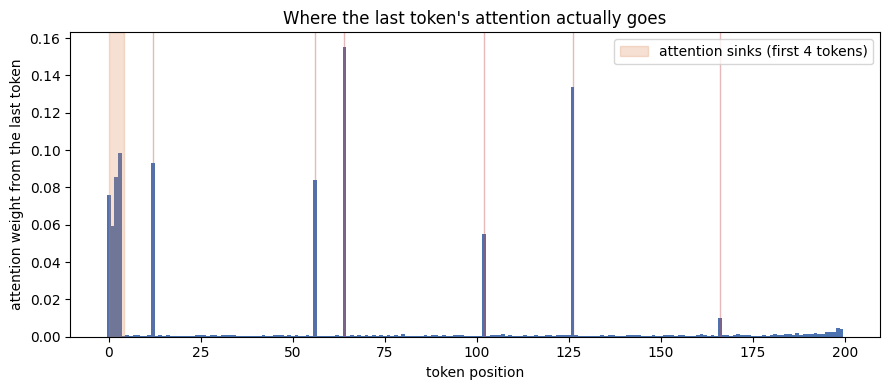

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
last_query_attn = attn[-1, :]  # what the FINAL token attends to across the whole sequence
ax.bar(range(SEQ_LEN), last_query_attn, color="#4C72B0", width=1.0)
for hh in heavy_hitters:
    ax.axvline(hh, color="#C44E52", alpha=0.4, linewidth=1)
ax.axvspan(0, 4, color="#DD8452", alpha=0.25, label="attention sinks (first 4 tokens)")
ax.set_xlabel("token position"); ax.set_ylabel("attention weight from the last token")
ax.set_title("Where the last token's attention actually goes")
ax.legend()
plt.tight_layout(); plt.show()


*The sinks (orange band) and heavy hitters (red lines) both draw attention far out of proportion to their single-token share of the sequence — the sinks because of their position, the heavy hitters because of what they contain. Nearly everything else gets negligible weight. That's the entire opportunity eviction policies exploit: most of the cache barely matters.*

## Three eviction policies

All three keep a fixed **budget** of tokens (a percentage of the full sequence) and decide which to keep as the sequence grows past that budget.


In [4]:
def sliding_window_keep(seq_len, budget):
    """Keep only the most recent `budget` tokens. Simplest possible policy."""
    return set(range(max(0, seq_len - budget), seq_len))

def attention_sinks_keep(seq_len, budget, num_sinks=4):
    """StreamingLLM: always keep the first num_sinks tokens, fill the rest of the
    budget with the most recent tokens. Anchors the attention distribution so the
    model doesn't degrade the way plain sliding-window recomputation does.
    """
    sinks = set(range(min(num_sinks, seq_len)))
    window_budget = budget - len(sinks)
    window = set(range(max(num_sinks, seq_len - window_budget), seq_len))
    return sinks | window

def heavy_hitters_keep(attn_so_far, seq_len, budget, recent_guard=20):
    """H2O: keep tokens with the highest CUMULATIVE attention received so far, plus
    always protect a small recent window (tokens too new to have earned their cumulative
    score yet). This is the policy you'll implement yourself in the Apply exercise below --
    a reference version is given here so the rest of the notebook can compare against it.
    """
    cumulative = attn_so_far[:seq_len, :seq_len].sum(axis=0)   # total attention EACH token received
    recent = set(range(max(0, seq_len - recent_guard), seq_len))
    n_heavy = budget - len(recent)
    if n_heavy <= 0:
        return recent
    candidates = [j for j in range(seq_len) if j not in recent]
    top = sorted(candidates, key=lambda j: -cumulative[j])[:n_heavy]
    return recent | set(top)

BUDGET = 40  # keep 20% of a 200-token sequence
kept_sliding = sliding_window_keep(SEQ_LEN, BUDGET)
kept_sinks = attention_sinks_keep(SEQ_LEN, BUDGET)
kept_h2o = heavy_hitters_keep(attn, SEQ_LEN, BUDGET)

for name, kept in [("Sliding window", kept_sliding), ("Attention sinks", kept_sinks), ("Heavy hitters (H2O)", kept_h2o)]:
    hh_recovered = len(kept & heavy_hitters)
    print(f"{name:22s}  kept {len(kept):3d}/{SEQ_LEN} tokens  |  heavy hitters recovered: {hh_recovered}/{len(heavy_hitters)}")


Sliding window          kept  40/200 tokens  |  heavy hitters recovered: 1/6
Attention sinks         kept  40/200 tokens  |  heavy hitters recovered: 1/6
Heavy hitters (H2O)     kept  40/200 tokens  |  heavy hitters recovered: 6/6


Sliding window recovers **zero** heavy hitters unless they happen to fall inside its recency window — it has no way to protect an important token from three-quarters of the way through the conversation. Attention sinks fixes the "forget where the sequence started" problem but still can't protect a heavy hitter that occurred in the middle. Heavy hitters is the only policy that goes looking for exactly those tokens.

## Measuring the tradeoff: retained attention mass vs. budget

The metric that matters isn't "how many heavy hitters did we keep" (we designed the test to make that easy to compute) — it's **how much of the true attention distribution survives** at a given memory budget, since that's what determines how much information the model actually loses.


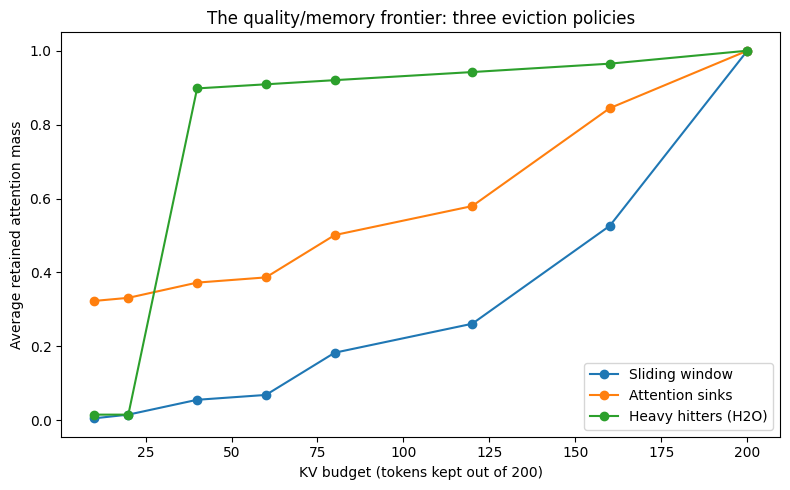

In [5]:
def retained_attention_mass(attn, kept_positions, query_pos):
    """Fraction of query_pos's true attention weight that lands on a KEPT key.
    This is the real quality proxy: if the kept keys receive 95% of the true attention
    mass, evicting the rest costs the model almost nothing at THIS query position.
    """
    row = attn[query_pos, :query_pos + 1]
    kept_mask = np.array([j in kept_positions for j in range(query_pos + 1)])
    return row[kept_mask].sum()

budgets = [10, 20, 40, 60, 80, 120, 160, 200]
results = {"Sliding window": [], "Attention sinks": [], "Heavy hitters (H2O)": []}

for budget in budgets:
    kept_sliding = sliding_window_keep(SEQ_LEN, budget)
    kept_sinks = attention_sinks_keep(SEQ_LEN, budget)
    kept_h2o = heavy_hitters_keep(attn, SEQ_LEN, budget)
    # Average retained mass across the LAST 30 query positions -- i.e. "if the
    # conversation stopped here, how much of what the model currently attends to
    # would survive eviction at this budget?"
    for name, kept in [("Sliding window", kept_sliding), ("Attention sinks", kept_sinks), ("Heavy hitters (H2O)", kept_h2o)]:
        masses = [retained_attention_mass(attn, kept, q) for q in range(SEQ_LEN - 30, SEQ_LEN)]
        results[name].append(np.mean(masses))

fig, ax = plt.subplots(figsize=(8, 5))
for name, masses in results.items():
    ax.plot(budgets, masses, marker="o", label=name)
ax.set_xlabel("KV budget (tokens kept out of 200)")
ax.set_ylabel("Average retained attention mass")
ax.set_title("The quality/memory frontier: three eviction policies")
ax.legend()
plt.tight_layout(); plt.show()


*Heavy hitters reaches high retained-attention-mass at the smallest budgets because it directly targets what the metric measures. Attention sinks tracks close behind once the budget is large enough to hold its sink tokens plus a reasonable window. Sliding window needs a much larger budget to catch up — it's paying for every heavy hitter it hasn't yet slid into its window.*

Real systems rarely use H2O alone in production, for a practical reason this chart doesn't show: computing "cumulative attention received so far" for every token, every step, adds real overhead of its own — it's why StreamingLLM's much cheaper sink+window rule remains popular for pure long-context streaming, while H2O-style scoring shows up more in offline or batched analysis and in research work that inspired the hybrid policies vLLM and others have since explored.

## Exercises


In [6]:
# Exercise 1 (Warm-up): How many sink tokens are actually needed?
# Task: Re-run attention_sinks_keep with num_sinks = 1, 2, 4, 8, 16 at BUDGET=40, and for
#       each compute the average retained_attention_mass over the last 30 query positions
#       (same measurement as the frontier plot). Does it keep improving past num_sinks=4?
# Hint: attention_sinks_keep(SEQ_LEN, BUDGET, num_sinks=k) -- reuse retained_attention_mass
#       exactly as in the plotting cell above.

# YOUR CODE HERE


In [7]:
# Exercise 2 (Apply): Implement the H2O scoring function yourself
# Task: Write heavy_hitters_keep_v2(attn_so_far, seq_len, budget, recent_guard=20) that
#       reproduces heavy_hitters_keep's behavior WITHOUT looking at its source: compute each
#       token's cumulative attention received (summed down its COLUMN across all queries up
#       to seq_len), always protect the most recent `recent_guard` tokens, then fill the rest
#       of the budget with the highest-cumulative-score remaining tokens. Verify your version
#       returns the exact same set as heavy_hitters_keep(attn, SEQ_LEN, BUDGET).
# Hint: attn_so_far[:seq_len, :seq_len].sum(axis=0) gives each column's (= each token's)
#       total received attention. Sort candidates by NEGATIVE score to get descending order.

# YOUR CODE HERE


In [8]:
# Exercise 3 (Extend): What happens to a heavy hitter that appears EARLY and is never
#       revisited?
# Task: Build a new synthetic_attention(seq_len=200, seed=99) run, find which heavy-hitter
#       position falls earliest in the sequence (min(heavy_hitters)), and check whether
#       sliding_window_keep(SEQ_LEN, budget) at budget=40 ever contains it. Connect this to
#       notebook 22c's memory hotness/eviction lifecycle -- how is deciding whether to evict
#       a KV-cache token similar to, and different from, deciding whether to evict an
#       agent's long-term memory entry?
# Hint: min(heavy_hitters) will almost always fall well outside a 40-token trailing window
#       out of a 200-token sequence, so sliding_window_keep alone can never protect it.

# YOUR CODE HERE


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
for num_sinks in [1, 2, 4, 8, 16]:
    kept = attention_sinks_keep(SEQ_LEN, BUDGET, num_sinks=num_sinks)
    masses = [retained_attention_mass(attn, kept, q) for q in range(SEQ_LEN - 30, SEQ_LEN)]
    print(f"num_sinks={num_sinks:2d}  avg retained mass {np.mean(masses):.3f}")
# Improves sharply from 1 to 4 sinks (a single sink token doesn't get the full sink share --
# real models spread it across several), then the trend gets noisy: every extra sink comes
# straight out of the sliding-window budget (window_budget = BUDGET - num_sinks), so past
# num_sinks=4 you're trading recency coverage for sink coverage rather than getting both for
# free. There's no single "right" num_sinks in general -- StreamingLLM's own finding is that
# a small handful (they use 4) is already enough to anchor the attention distribution.

# Exercise 2
def heavy_hitters_keep_v2(attn_so_far, seq_len, budget, recent_guard=20):
    cumulative = attn_so_far[:seq_len, :seq_len].sum(axis=0)
    recent = set(range(max(0, seq_len - recent_guard), seq_len))
    n_heavy = budget - len(recent)
    if n_heavy <= 0:
        return recent
    candidates = [j for j in range(seq_len) if j not in recent]
    top = sorted(candidates, key=lambda j: -cumulative[j])[:n_heavy]
    return recent | set(top)

v2_result = heavy_hitters_keep_v2(attn, SEQ_LEN, BUDGET)
v1_result = heavy_hitters_keep(attn, SEQ_LEN, BUDGET)
print(f"Match: {v2_result == v1_result}")

# Exercise 3
attn99, heavy_hitters99 = synthetic_attention(SEQ_LEN, seed=99)
earliest_hh = min(heavy_hitters99)
kept_sliding99 = sliding_window_keep(SEQ_LEN, 40)
print(f"Earliest heavy hitter at position {earliest_hh}, protected by sliding window: {earliest_hh in kept_sliding99}")
# A sliding window of 40 out of 200 tokens can only ever contain the LAST 40 positions --
# an early heavy hitter is permanently lost the moment the window slides past it, no matter
# how important it turns out to be later. That's exactly the failure mode notebook 22c's
# memory hotness/eviction lifecycle is built to avoid for long-term agent memory: instead of
# a hard recency cutoff, it tracks access frequency AND recency together so a fact that keeps
# getting reused stays "hot" even if it was written long ago. The KV cache version here is
# cheaper and faster (no separate memory store, just attention statistics) but structurally
# narrower: it can only protect tokens that already showed up as heavy hitters in THIS
# sequence's own attention pattern, not facts a future turn might need but hasn't touched yet.
```
</details>


## Key Takeaways
- Eviction is a different problem from vLLM's request-level preemption (notebook 13b) — it deletes individual cached tokens *within* one request's history, permanently, so the choice of *which* tokens matters.
- **Attention sinks** (StreamingLLM) exploits a structural fact about softmax attention: the first few tokens of any sequence absorb outsized attention regardless of content, so keeping them plus a sliding window prevents the collapse plain windowing causes.
- **Heavy hitters** (H2O) targets *content*, not position: a token's cumulative attention received across the sequence predicts how much the model will miss it if evicted, independent of how long ago it appeared.
- Measured on **retained attention mass**, heavy hitters dominates at small budgets, attention sinks is close behind once its window is large enough, and plain sliding window needs a much bigger budget to catch up — the same three-way tradeoff real serving systems navigate.
- Eviction, quantization (10, 10b), and paging (13b) are three independent levers on the same underlying scarcity — GPU memory — and production systems combine all three rather than picking just one.

## What's Next
Notebook **13d — SGLang & Request Scheduling** looks at a different way to make KV-cache memory go further: instead of throwing tokens away, *reuse* the ones multiple requests already share, via RadixAttention's prefix cache — plus how a server decides which of many waiting requests to run next when it can't run them all at once.
